In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

from warnings import filterwarnings
filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.models import Sequential

from tensorflow.keras.optimizers.legacy import Optimizer
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.regularizers import l2

from tensorflow.keras.optimizers import AdamW
import pickle

from time import perf_counter
from scipy.stats import norm


2025-04-23 16:27:22.573774: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-23 16:27:22.635787: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-23 16:27:22.636579: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-23 16:27:22.638083: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-23 16:27:22.646653: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-23 16:27:22.647930: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [2]:
counts = pd.read_csv('/work/counts_pred.csv')
X = pd.read_csv('/work/preprocessed.csv')
X['No Of Withdrawals'] = StandardScaler().fit_transform(counts)

In [3]:
y = pd.read_csv('/work/target.csv')['Total amount Withdrawn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

y_train_norm = (y_train - y_train.min()) / (y_train.max() - y_train.min())
y_test_norm = (y_test - y_test.min()) / (y_test.max() - y_test.min())
# y_val_norm = (y_val - y_val.min()) / (y_val.max() - y_val.min())

In [87]:
# === 1. Build Hybrid MC Dropout Model ===
def create_hybrid_model(input_dim, dropout_rate=0.3):

    inputs = tf.keras.Input(shape=(input_dim,))
    
    x = Dense(64, activation='relu', kernel_regularizer=l2(0.001))(inputs)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)

    x = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = Dropout(dropout_rate)(x)

    x = Dense(32, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = Dropout(dropout_rate)(x)
    x = BatchNormalization()(x)

    mean_output = Dense(1, name='mean', activation='softplus')(x)

    log_var_output = Dense(1, activation='softplus')(x)
    log_var_output = tf.keras.layers.Lambda(lambda x: tf.clip_by_value(x, 1e-6, 5), name='log_var')(log_var_output)

    outputs = tf.keras.layers.Concatenate()([mean_output, log_var_output])
    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    return model

In [90]:

def nll_loss_with_reg(y_true, y_pred):
    y_pred_mean = y_pred[:, 0]
    y_pred_log_var = y_pred[:, 1]
    penalty_weight = 0.01
    mse = tf.square(y_true - y_pred_mean)
    precision = tf.exp(-y_pred_log_var)
    nll = 0.5 * tf.math.log(2. * np.pi) + 0.5 * y_pred_log_var + 0.5 * precision * mse
    
    # Regularize log_var so it doesn't go extreme
    penalty = penalty_weight * tf.reduce_mean (tf.square(y_pred_log_var))
    return tf.reduce_mean(nll) + penalty
    

# # === 2. Custom wrapper loss for Keras ===
# class HybridLoss(tf.keras.losses.Loss):
#     def __init__(self, penalty_weight=0.01):
#         super().__init__()
#         self.penalty_weight = penalty_weight

#     def call(self, y_true, y_pred):
#         y_pred_mean, y_pred_log_var = y_pred[:, 0:1], y_pred[:, 1:2]
#         return nll_loss(y_true, y_pred_mean, y_pred_log_var, self.penalty_weight)


def train_hybrid_model(X_train, y_train, validation_split=0, verbose=0, dropout_rate=0.2, epochs=200):
  
    input_dim = X_train.shape[1]
    model = create_hybrid_model(input_dim, dropout_rate)

    optimizer = AdamW(learning_rate=1e-3)
    model.compile(optimizer=optimizer, loss=nll_loss_with_reg) 
    
    callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='loss', factor=0.5, patience=5, min_lr=1e-6, verbose=verbose)

    history = model.fit(X_train, y_train, epochs=epochs, validation_split=validation_split, callbacks=[callback], verbose=verbose)
    
    return model, history


In [93]:
model, history = train_hybrid_model(X_train, y_train_norm, validation_split=0.1, verbose=1)

Epoch 1/200
Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7fe619474e80>>
Traceback (most recent call last):
  File "/toolkit-cache/0.2.14/python3.10/kernel-libs/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 
286/286 [==============================] - 25s 4ms/step - loss: 1.4059 - val_loss: 1.1518 - lr: 0.0010
Epoch 2/200
286/286 [==============================] - 1s 2ms/step - loss: 1.1291 - val_loss: 1.0716 - lr: 0.0010
Epoch 3/200
286/286 [==============================] - 1s 2ms/step - loss: 1.0653 - val_loss: 1.0367 - lr: 0.0010
Epoch 4/200
286/286 [==============================] - 1s 3ms/step - loss: 1.0315 - val_loss: 1.0107 - lr: 0.0010
Epoch 5/200
286/286 [==============================] - 1s 2ms/step - loss: 1.0066 - val_loss: 0.9905 - lr: 0.0010
Epoch 6/200
286/286 [===========================

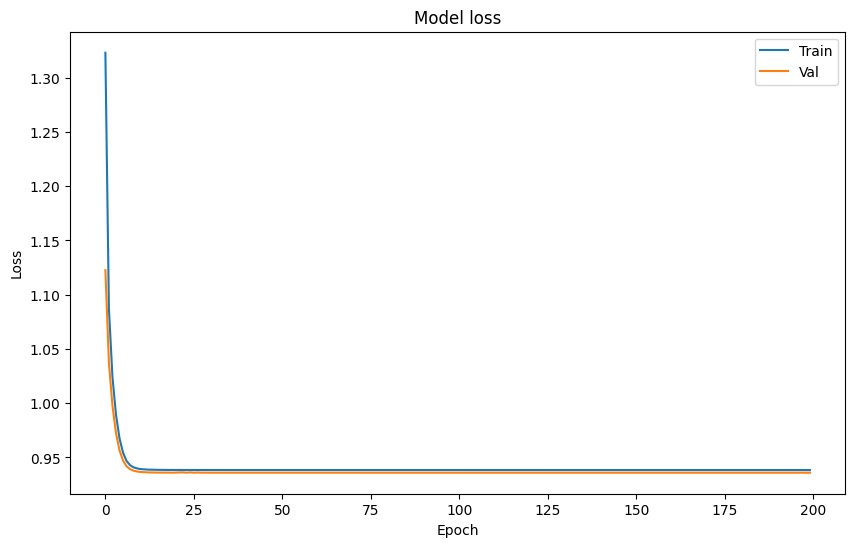

In [277]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

In [278]:
t1 = perf_counter()

model, history = train_hybrid_model(X_train, y_train_norm, validation_split=0.0)

model.save('/work/bayesian_dropout_amt.h5')
model.save('/work/bayesian_dropout_amt.keras')

t2 = perf_counter()
print(f'Training time: {t2 - t1: .2f} seconds')

Training time:  127.15 seconds


In [15]:

def predict_with_hybrid_pi(model, X_input, alpha=0.7):

    n_samples=X_input.shape[0]

    X_input = tf.convert_to_tensor(X_input, dtype=tf.float32)

    mean_preds = []
    var_preds = []

    for _ in range(n_samples):
        preds = model(X_input, training=True)
        mean = preds[:, 0].numpy().flatten()
        var = np.exp(preds[:, 1].numpy().flatten())
        mean_preds.append(mean)
        var_preds.append(var)

    mean_preds = np.array(mean_preds)
    var_preds = np.array(var_preds)

    mean_final = mean_preds.mean(axis=0)
    epistemic_var = mean_preds.var(axis=0)
    aleatoric_var = var_preds.mean(axis=0)
    total_std = np.sqrt(epistemic_var + aleatoric_var)

    z = norm.ppf(1 - alpha / 2)
    lower = mean_final - z * total_std 
    upper = mean_final + z * total_std 
    
    return mean_final, lower, upper


In [411]:

t1 = perf_counter()

# Convert test input to tensor
X_input = tf.convert_to_tensor(X_test, dtype=tf.float32)

# Predict with uncertainty
mean, lower, upper = predict_with_hybrid_pi(model, X_input)

t2 = perf_counter()

print(f'Prediction with Monte Carlo Dropout Training time: {t2 - t1: .2f} seconds')

amt = mean * (y_test.max() - y_test.min()) + y_test.min()
lb_amt = lower * (y_test.max() - y_test.min()) + y_test.min()
ub_amt = upper * (y_test.max() - y_test.min()) + y_test.min()

amt = amt.astype('int')
lb_amt = lb_amt.astype('int')
ub_amt = ub_amt.astype('int')

Prediction with Monte Carlo Dropout Training time:  42.61 seconds


In [412]:
def compute_picp(y_lower, y_upper, y_true):
    return np.mean(np.logical_and(y_true >= y_lower, y_true <= y_upper))

def compute_pinrw(y_lower, y_upper, y_true):
    R = np.max(y_true) - np.min(y_true)
    width = np.sqrt(np.mean((y_upper - y_lower) ** 2))
    return width / R

def compute_pinrw(y_lower, y_upper, y_true):
    R = np.max(y_true) - np.min(y_true)
    width = np.sqrt(np.mean((y_upper - y_lower) ** 2))
    return width / R

def cwc_loss_numpy(y_lower, y_upper, y_true, gamma=50, eta=50, mu=0.95):
    picp = compute_picp(y_lower, y_upper, y_true)
    pinrw = compute_pinrw(y_lower, y_upper, y_true)
    penalty = np.exp(eta * (mu - picp))
    cwc = pinrw * (1 + gamma * penalty)
    mpiw = np.mean(y_upper - y_lower)

    return cwc, picp, mpiw, pinrw

In [417]:

cwc, picp, mpiw, pinrw = cwc_loss_numpy(lb_amt, ub_amt, y_test, gamma=50, eta=50, mu=0.95)
outcome = (y_test >= lb_amt) & (y_test <= ub_amt)

result = pd.DataFrame({'Original': y_test, 'Predicted': amt,
                        'Lower Bound': lb_amt, 'Upper Bound': ub_amt,
                        'Outcome': outcome})


result.to_csv(f'Results_Bayesian_amt.csv', index=False)


In [414]:
print('PICP: ', picp)
print('PINRW: ', pinrw)
print('CWC: ', cwc)
print('MPIW: ', mpiw)

PICP:  0.954240631163708
PINRW:  0.7706400262574875
CWC:  31.940685129374852
MPIW:  939179.0


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=6c5dcd7e-ee44-459a-9dd6-5c39b2404cb3' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>